In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from ase.io import read
import pandas as pd
import os

from flonacomldft.utils.io_utils import load_pickle_file, get_path, load_csv_file
from flonacomldft.internal_coordinates import Coordinates_mapping

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft'

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

In [3]:
adaptives_mcmc_dft = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_dft_path]
adaptives_mcmc_mlp = [load_pickle_file(adaptive_file, DFT_SIMS_PATH) for adaptive_file in adaptive_mlp_path]

### 1. Adaptive DFT

In [4]:
#adaptives_mcmc_dft[0]['dict_flows_training'][-2][0]['model']

In [5]:
def flatten_xs(xs):
    xs_flatten = []

    for i in range(xs.shape[1]):
        xs_flatten.append(xs[:, i, :])

    return torch.cat(xs_flatten)

def flatten_us(us):
    us_flatten = []

    for i in range(us.shape[1]):
        us_flatten.append(us[:, i])

    return torch.cat(us_flatten)

In [7]:
def MCMC_data(adaptives):
    
    xs = {i: torch.cat(adaptives[i]['xs']) for i in range(len(adaptives))}
    us = {i: torch.cat(adaptives[i]['us']) for i in range(len(adaptives))}
    
    xs_reshape = {key: flatten_xs(xs[key]) for key in xs.keys()}
    us_reshape = {key: flatten_us(us[key]) for key in us.keys()}

    mcmc_data = {key: torch.cat([xs_reshape[key], 
                                us_reshape[key].reshape(-1, 1)], dim=1) for key in xs_reshape.keys()}

    return mcmc_data

#### 1.a MCMC samples

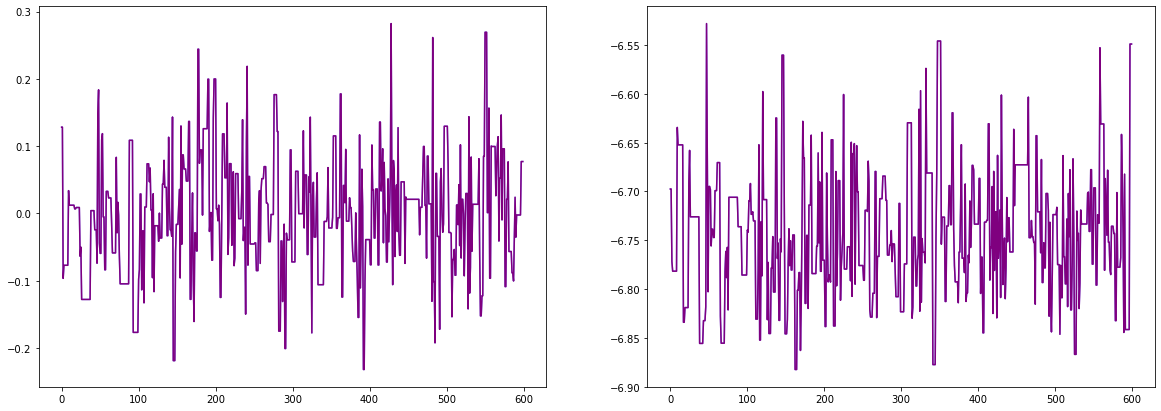

In [8]:
xs = {i: torch.cat(adaptives_mcmc_dft[i]['xs']) for i in range(len(adaptives_mcmc_dft))}
us = {i: torch.cat(adaptives_mcmc_dft[i]['us']) for i in range(len(adaptives_mcmc_dft))}

xs_reshape = {key: flatten_xs(xs[key]) for key in xs.keys()}
us_reshape = {key: flatten_us(us[key]) for key in us.keys()}

fig, axs = plt.subplots(1, 2, figsize=(20, 7))
i=15
#plotting one coordinate with new shape to check if it is correct
axs[0].plot(xs[0][:, i, :].detach().numpy().T[1], c='blue', alpha=1)
axs[0].plot(xs_reshape[0].detach().numpy().T[1][i*600:600*(i+1)], c='red', alpha=0.5) 

#plotting energy with new shape to check if it is correct
axs[1].plot(us[0][:, i].detach().numpy().T, c='blue', alpha=1)
axs[1].plot(us_reshape[0].detach().numpy()[i*600:600*(i+1)], c='red', alpha=0.5)

In [10]:
mcmc_data_dft = MCMC_data(adaptives_mcmc_dft)
mcmc_data_mlp = MCMC_data(adaptives_mcmc_mlp)

(array([1.5510e+03, 8.6200e+03, 1.1128e+04, 5.9890e+03, 2.0610e+03,
        5.2300e+02, 1.0700e+02, 1.9000e+01, 1.0000e+00, 1.0000e+00]),
 array([-6.8267937, -6.7577314, -6.6886697, -6.619608 , -6.5505457,
        -6.4814835, -6.4124217, -6.34336  , -6.2742977, -6.2052355,
        -6.1361737], dtype=float32),
 <BarContainer object of 10 artists>)

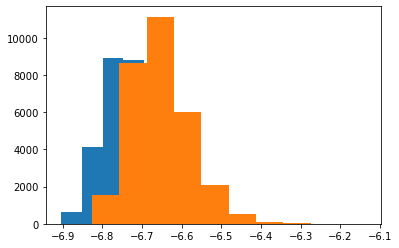

In [15]:
plt.hist(mcmc_data_mlp[0][:, -1].detach().numpy())
plt.hist(mcmc_data_mlp[1][:, -1].detach().numpy())

In [16]:
path_to_save = '/mnt/home/amolina/ceph/ml-dft/data_free_energy/'
path_to_save

'/mnt/home/amolina/ceph/ml-dft/data_free_energy/'

In [17]:
def save_data( isomer_label, dist, origin, path_to_save_df, xs_rc):
        
    cols = ['rc_{:d}'.format(i) for i in range(12)] + ['Energy']
    df = pd.DataFrame(xs_rc.detach().numpy(), columns=cols)
    
    df.to_csv(path_to_save_df + '/is{:d}_{:s}_{:s}.csv'.format(isomer_label,
                                                            dist, 
                                                            origin,),
                                                            index=False)


<AxesSubplot:ylabel='Count'>

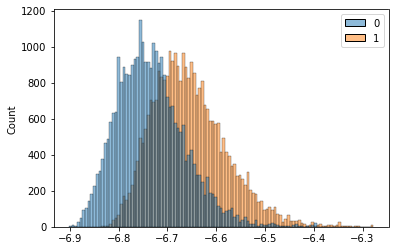

In [24]:
dataset = [ load_csv_file('is0_mcmc_dft.csv', path_to_save),
    load_csv_file('is1_mcmc_dft.csv', path_to_save)]

energies = {i: dataset[i][:, -1] for i in range(len(dataset))}

import seaborn as sns

sns.histplot(energies)


In [18]:
save_data(0, 'mcmc', 'dft', path_to_save, xs_rc=mcmc_data_dft[0])
save_data(1, 'mcmc', 'dft', path_to_save, xs_rc=mcmc_data_dft[1])
save_data(0, 'mcmc', 'mlp', path_to_save, xs_rc=mcmc_data_mlp[0])
save_data(1, 'mcmc', 'mlp', path_to_save, xs_rc=mcmc_data_mlp[1])

### 1.b Flow samples

In [12]:
path_to_flow_samples = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data'

path_to_flow_samples_dft = ['results_fe_dft_isomer_0_29414610/is0_samples_rc_29414610.csv',
                            'results_fe_dft_isomer_1_29414611/is1_samples_rc_29414611.csv']

path_to_flow_samples_mlp = ['results_fe_mlp_isomer_0_29414612/is0_samples_rc_29414612.csv',
                            'results_fe_mlp_isomer_1_29414613/is1_samples_rc_29414613.csv']

samples_flow_dft = {key: load_csv_file(path_to_flow_samples_dft[key], path_to_flow_samples) for key in [0, 1]}
samples_flow_mlp = {key: load_csv_file(path_to_flow_samples_mlp[key], path_to_flow_samples) for key in [0, 1]}

In [13]:
save_data(0, 'flow', 'dft', path_to_save, xs_rc=samples_flow_dft[0])
save_data(1, 'flow', 'dft', path_to_save, xs_rc=samples_flow_dft[1])
save_data(0, 'flow', 'mlp', path_to_save, xs_rc=samples_flow_mlp[0])
save_data(1, 'flow', 'mlp', path_to_save, xs_rc=samples_flow_mlp[1])

### 1.c MD

In [14]:
path_to_md = get_path() + '/andersen/int_coords'

md_files = ['27037382_is0_andersen.csv', 
            '27037385_is1_andersen.csv']

md_internal = {key: load_csv_file(md_files[key], path_to_md)[:10000] for key in [0, 1]}

In [15]:
coord_mapping = Coordinates_mapping()
md_rc = {key: coord_mapping.get_real_centered_from_internal(md_internal[key][:, :12], 
                                                              isomer=key, 
                                                              energies=md_internal[key][:, 12],
                                                              temperature=350) 
                                                              for key in [0, 1]}

md_data = {key: torch.cat((md_rc[key][0], md_rc[key][2].reshape(-1, 1)), dim=1) for key in [0, 1]}

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [16]:
save_data(0, '', 'md', path_to_save, xs_rc=md_data[0])
save_data(1, '', 'md', path_to_save, xs_rc=md_data[1])

In [17]:
def read_sample_get_rc(path, isomer):

    list_file_md = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    list_file_md.remove('init_calc.out')
    molecules = [read(path + '/' + file) for file in list_file_md]
    flow_md_zmat = coord_mapping.get_internal_from_trajectory(molecules, isomer=isomer, temperature=350)
    flow_md_rc = coord_mapping.get_real_centered_from_internal(flow_md_zmat[:, :12], 
                                                                  isomer=isomer, 
                                                                  energies=flow_md_zmat[:, 12],
                                                                  temperature=350)
    
    return torch.cat((flow_md_rc[0], flow_md_rc[2].reshape(-1, 1)), dim=1)

In [19]:
path_to_flow_md = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data' 

path_flow_md_samples = ['results_fe_md_isomer_0_29473500/DFTComputations_is0_29473500', 
                        'results_fe_md_isomer_1_29473501/DFTComputations_is1_29473501']

flow_md_samples = {key: read_sample_get_rc(path_to_flow_md + '/' + path_flow_md_samples[key], isomer=key) for key in [0, 1]}

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [20]:
save_data(0, 'flow', 'md', path_to_save, xs_rc=flow_md_samples[0])
save_data(1, 'flow', 'md', path_to_save, xs_rc=flow_md_samples[1])                                                             